# **Hackathon: Exploring the Hottest Topics in Machine Learning**

## Step 1: Data loading and inspection

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/NLP_Hackathon1/papers.csv')

In [4]:
df.shape

(7241, 7)

In [5]:
# First 5 rows
df.head(5)

,id,year,title,event_type,pdf_name,abstract,paper_text
0,1,1987,Self-Organization of Associative Database and ...,NaN,1-self-organization-of-associative-database-an...,Abstract Missing,767\n\nSELF-ORGANIZATION OF ASSOCIATIVE DATABA...
1,10,1987,A Mean Field Theory of Layer IV of Visual Cort...,NaN,10-a-mean-field-theory-of-layer-iv-of-visual-c...,Abstract Missing,683\n\nA MEAN FIELD THEORY OF LAYER IV OF VISU...
2,100,1988,Storing Covariance by the Associative Long-Ter...,NaN,100-storing-covariance-by-the-associative-long...,Abstract Missing,394\n\nSTORING COVARIANCE BY THE ASSOCIATIVE\n...
3,1000,1994,Bayesian Query Construction for Neural Network...,NaN,1000-bayesian-query-construction-for-neural-ne...,Abstract Missing,Bayesian Query Construction for Neural\nNetwor...
4,1001,1994,"Neural Network Ensembles, Cross Validation, an...",NaN,1001-neural-network-ensembles-cross-validation...,Abstract Missing,"Neural Network Ensembles, Cross\nValidation, a..."


In [6]:
# Lat 5 rows
df.tail(5)

,id,year,title,event_type,pdf_name,abstract,paper_text
7236,994,1994,Single Transistor Learning Synapses,NaN,994-single-transistor-learning-synapses.pdf,Abstract Missing,Single Transistor Learning Synapses\n\nPaul Ha...
7237,996,1994,"Bias, Variance and the Combination of Least Sq...",NaN,996-bias-variance-and-the-combination-of-least...,Abstract Missing,"Bias, Variance and the Combination of\nLeast S..."
7238,997,1994,A Real Time Clustering CMOS Neural Engine,NaN,997-a-real-time-clustering-cmos-neural-engine.pdf,Abstract Missing,A Real Time Clustering CMOS\nNeural Engine\nT....
7239,998,1994,Learning direction in global motion: two class...,NaN,998-learning-direction-in-global-motion-two-cl...,Abstract Missing,Learning direction in global motion: two\nclas...
7240,999,1994,Correlation and Interpolation Networks for Rea...,NaN,999-correlation-and-interpolation-networks-for...,Abstract Missing,Correlation and Interpolation Networks for\nRe...


In [7]:
df.columns

Index(['id', 'year', 'title', 'event_type', 'pdf_name', 'abstract',
       'paper_text'],
      dtype='object')

In [8]:
df.dtypes

,0
id,int64
year,int64
title,object
event_type,object
pdf_name,object
abstract,object
paper_text,object


In [9]:
df.isnull().sum()

,0
id,0
year,0
title,0
event_type,4819
pdf_name,0
abstract,0
paper_text,0


## Step 2: Data preprocessing

In [10]:
# Keep only the important columns
papers = df[['year', 'title', 'abstract']].copy()

In [20]:
# Check for missing or null values

print(papers.isnull().sum())

year        0
title       0
abstract    0
dtype: int64


## Step 3: Data visualization

### Number of publications per year

In [14]:
# Group by year and count the number of papers published
papers_per_year = papers.groupby('year').size()

In [15]:
# Display the counts
print("Number of papers published per year:")
print(papers_per_year)

Number of papers published per year:
year
1987     90
1988     94
1989    101
1990    143
1991    144
1992    127
1993    158
1994    140
1995    152
1996    152
1997    150
1998    151
1999    150
2000    152
2001    197
2002    207
2003    198
2004    207
2005    207
2006    204
2007    217
2008    250
2009    262
2010    292
2011    306
2012    368
2013    360
2014    411
2015    403
2016    569
2017    679
dtype: int64


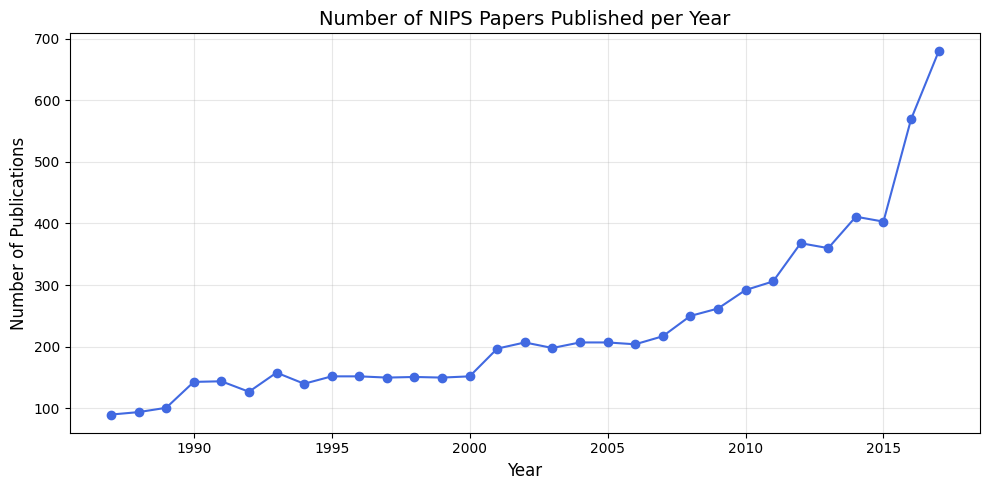

In [16]:
# Plot the trend
plt.figure(figsize=(10,5))
plt.plot(papers_per_year.index, papers_per_year.values, marker='o', linestyle='-', color='royalblue')
plt.title('Number of NIPS Papers Published per Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Publications', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4: Text data preprocessing

In [17]:
# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [24]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [22]:
# Function to clean, tokenize, stem, and lemmatize text
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation, numbers, and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and short tokens
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    # Apply stemming
    stemmed = [stemmer.stem(word) for word in tokens]

    # Apply lemmatization
    lemmatized = [lemmatizer.lemmatize(word) for word in stemmed]

    # Join tokens back into a single string
    return " ".join(lemmatized)

In [25]:
# Apply preprocessing to title and abstract columns
papers['title_processed'] = papers['title'].apply(preprocess_text)
papers['abstract_processed'] = papers['abstract'].apply(preprocess_text)

In [27]:
print("\nSample processed titles:")
print(papers[['title', 'title_processed']].head())


Sample processed titles:
                                               title  \
0  Self-Organization of Associative Database and ...   
1  A Mean Field Theory of Layer IV of Visual Cort...   
2  Storing Covariance by the Associative Long-Ter...   
3  Bayesian Query Construction for Neural Network...   
4  Neural Network Ensembles, Cross Validation, an...   

                                     title_processed  
0                    selforgan associ databas applic  
1  mean field theori layer visual cortex applic a...  
2  store covari associ longterm potenti depress s...  
3      bayesian queri construct neural network model  
4     neural network ensembl cross valid activ learn  


In [28]:
print("\nSample processed abstracts:")
print(papers[['abstract', 'abstract_processed']].head())


Sample processed abstracts:
           abstract abstract_processed
0  Abstract Missing      abstract miss
1  Abstract Missing      abstract miss
2  Abstract Missing      abstract miss
3  Abstract Missing      abstract miss
4  Abstract Missing      abstract miss


## Step 5: Bag of Words representation

In [29]:
from sklearn.feature_extraction.text import CountVectorizer

In [30]:
# Combine title and abstract for a stronger representation
papers['text_combined'] = papers['title_processed'] + " " + papers['abstract_processed']

In [35]:
print(papers['text_combined'].head())

0        selforgan associ databas applic abstract miss
1    mean field theori layer visual cortex applic a...
2    store covari associ longterm potenti depress s...
3    bayesian queri construct neural network model ...
4    neural network ensembl cross valid activ learn...
Name: text_combined, dtype: object


In [36]:
print(vectorizer.get_feature_names_out())


['abil' 'abl' 'abstract' 'acceler' 'access' 'accord' 'account' 'accur'
 'accuraci' 'achiev' 'across' 'action' 'activ' 'adapt' 'addit' 'address'
 'advanc' 'advantag' 'adversari' 'affect' 'affin' 'agent' 'aggreg' 'aim'
 'algorithm' 'align' 'alloc' 'allow' 'almost' 'along' 'also' 'altern'
 'although' 'among' 'amount' 'analog' 'analys' 'analysi' 'analyt' 'analyz'
 'annot' 'anoth' 'answer' 'appear' 'appli' 'applic' 'approach' 'appropri'
 'approxim' 'arbitrari' 'architectur' 'area' 'argu' 'aris' 'arm' 'art'
 'artifici' 'aspect' 'assess' 'assign' 'associ' 'assum' 'assumpt'
 'asymptot' 'asynchron' 'attempt' 'attent' 'attribut' 'augment'
 'autoencod' 'automat' 'avail' 'averag' 'avoid' 'backpropag' 'balanc'
 'bandit' 'base' 'baselin' 'basi' 'basic' 'batch' 'bay' 'bayesian' 'becom'
 'behavior' 'belief' 'benchmark' 'benefit' 'best' 'better' 'beyond' 'bia'
 'bias' 'binari' 'biolog' 'blind' 'block' 'boltzmann' 'boost' 'bound'
 'boundari' 'brain' 'broad' 'budget' 'build' 'calcul' 'calibr' 'call'
 'ca

In [37]:
print(papers[['title_processed', 'abstract_processed', 'text_combined']].head())


                                     title_processed abstract_processed  \
0                    selforgan associ databas applic      abstract miss   
1  mean field theori layer visual cortex applic a...      abstract miss   
2  store covari associ longterm potenti depress s...      abstract miss   
3      bayesian queri construct neural network model      abstract miss   
4     neural network ensembl cross valid activ learn      abstract miss   

                                       text_combined  
0      selforgan associ databas applic abstract miss  
1  mean field theori layer visual cortex applic a...  
2  store covari associ longterm potenti depress s...  
3  bayesian queri construct neural network model ...  
4  neural network ensembl cross valid activ learn...  


In [38]:
print(X.shape)


(7241, 1000)


In [39]:
# Initialize the CountVectorizer
vectorizer = CountVectorizer(max_features=1000)  # use top 1000 most frequent words
X = vectorizer.fit_transform(papers['text_combined'])

In [40]:
print(X.shape)

(7241, 1000)


In [32]:
# Convert to a DataFrame for easier viewing
bow_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

In [41]:
print("\nBag of Words representation (first 5 papers):")
print(bow_df.head(15))


Bag of Words representation (first 5 papers):
    abil  abl  abstract  acceler  access  accord  account  accur  accuraci  \
0      0    0         1        0       0       0        0      0         0   
1      0    0         1        0       0       0        0      0         0   
2      0    0         1        0       0       0        0      0         0   
3      0    0         1        0       0       0        0      0         0   
4      0    0         1        0       0       0        0      0         0   
5      0    0         1        0       0       0        0      0         0   
6      0    0         1        0       0       0        0      0         0   
7      0    0         1        0       0       0        0      0         0   
8      0    0         1        0       0       0        0      0         0   
9      0    0         1        0       0       0        0      0         0   
10     0    0         1        0       0       0        0      0         0   
11     0    0    

### Why the output contains a lot of zeros?

A zero in the Bag of Words matrix means the corresponding word is not present in that specific paper. This high number of zeros is normal and expected because the matrix is sparse, and it does not mean the CountVectorizer is a bad way to represent your data.

A more advanced representation is TF-IDF Vectorization to weight the words by importance.

In [34]:
# The shape of the matrix
print("\nShape of BoW matrix:", X.shape)


Shape of BoW matrix: (7241, 1000)


## Exploratory analysis with word clouds

In [42]:
# Join all processed titles into one long string
titles_string = " ".join(papers['title_processed'])

In [43]:
# Create a WordCloud object
wc_titles = WordCloud(width=1000, height=500, background_color='white', colormap='viridis')

In [44]:
# Generate the word cloud
wc_titles.generate(titles_string)

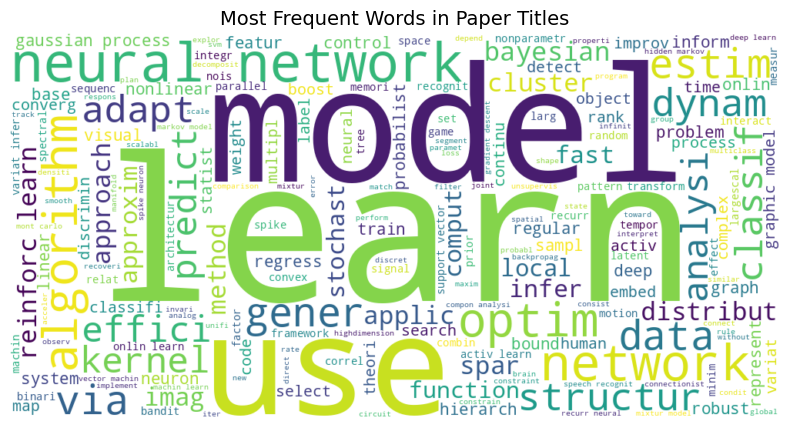

In [45]:
# Display the word cloud
plt.figure(figsize=(10,5))
plt.imshow(wc_titles, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Paper Titles', fontsize=14)
plt.show()

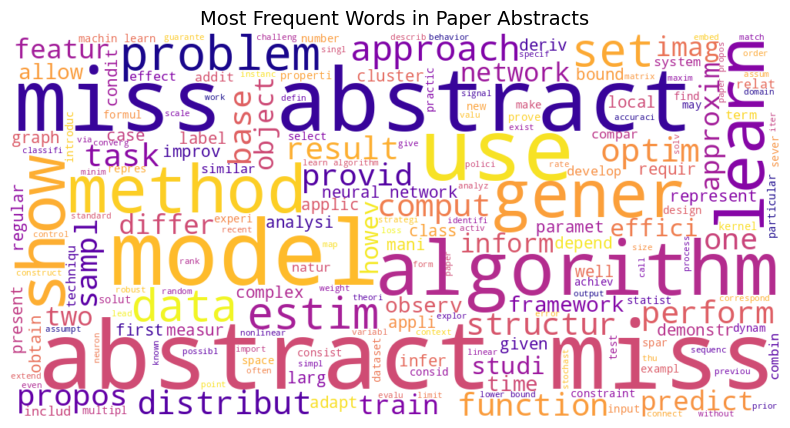

In [46]:
# Word Cloud for Abstracts
abstracts_string = " ".join(papers['abstract_processed'])

wc_abstracts = WordCloud(width=1000, height=500, background_color='white', colormap='plasma')
wc_abstracts.generate(abstracts_string)

plt.figure(figsize=(10,5))
plt.imshow(wc_abstracts, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Paper Abstracts', fontsize=14)
plt.show()